In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Entering the file from Google Drive
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/plantvillage'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/plantvillage


In [3]:
# check list for Classes
classes = os.listdir(extract_path)
print("Number of classes:", len(classes))
print("Classes:", classes[:10])

Number of classes: 2
Classes: ['PlantVillage', 'plantvillage']


In [4]:
import os

# Internal documents path
inner_path = os.path.join(extract_path, 'PlantVillage')  # یا 'plantvillage'

# classes
classes = os.listdir(inner_path)
print("Number of classes:", len(classes))
print("Classes:", classes[:10])


Number of classes: 15
Classes: ['Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Pepper__bell___Bacterial_spot', 'Potato___Late_blight', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Potato___healthy', 'Pepper__bell___healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [5]:
######--------PERPROCESSING--------######
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import os

In [6]:
# Transforming: Resize → Tensor → Normalize + Augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])


In [7]:
# Dataset path
data_dir = os.path.join(extract_path, "PlantVillage")

# Make a Dataset with transforms
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Number of total Images
print("Total images:", len(dataset))
print("Number of classes:", len(dataset.classes))
print("Classes:", dataset.classes)


Total images: 20638
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [8]:
# Dividing Percent
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print("Train set:", len(train_set))
print("Validation set:", len(val_set))
print("Test set:", len(test_set))


Train set: 14446
Validation set: 4127
Test set: 2065


In [9]:
# DtaLoader
batch_size = 32

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


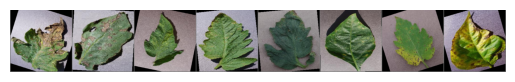

Labels: ['Tomato_Septoria_leaf_spot', 'Potato___Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Septoria_leaf_spot', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Pepper__bell___Bacterial_spot']


In [10]:
# Showing some Images from Dataset
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    np_img = img.numpy().transpose((1, 2, 0))
    plt.imshow(np_img)
    plt.axis("off")
    plt.show()

# Making a batch from train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", [dataset.classes[l] for l in labels[:8]])


In [11]:
###### ------- Making a simple Model with CNN------######

import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=15):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 56 * 56, 256)   # 224x224 → after two times pooling = 56x56
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [12]:
# Difin the Model Loss and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(dataset.classes)
model = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [13]:
# Training Loop
num_epochs = 5  # just for testing

for epoch in range(num_epochs):
    running_loss = 0.0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Gradin 0
        optimizer.zero_grad()

        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward + optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 1.4108
Epoch [2/5], Loss: 0.6712
Epoch [3/5], Loss: 0.5250
Epoch [4/5], Loss: 0.4410
Epoch [5/5], Loss: 0.3825


In [14]:
# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 85.75%


In [15]:
##### ----- Transfering Learning with ResNet50 -----######
import torchvision.models as models

# a Model ResNet50 by pretraing ImageNet
model_resnet = models.resnet50(pretrained=True)

# Changeing the last layer to fit with our 15 classes
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, num_classes)

model_resnet = model_resnet.to(device)

# Loss و Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


In [16]:
# Training Loop
num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0
    model_resnet.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.2779
Epoch [2/10], Loss: 0.0745
Epoch [3/10], Loss: 0.0567
Epoch [4/10], Loss: 0.0397
Epoch [5/10], Loss: 0.0378
Epoch [6/10], Loss: 0.0286
Epoch [7/10], Loss: 0.0308
Epoch [8/10], Loss: 0.0348
Epoch [9/10], Loss: 0.0231
Epoch [10/10], Loss: 0.0267


In [17]:
model_resnet.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy (ResNet50): {100 * correct / total:.2f}%")


Validation Accuracy (ResNet50): 99.25%


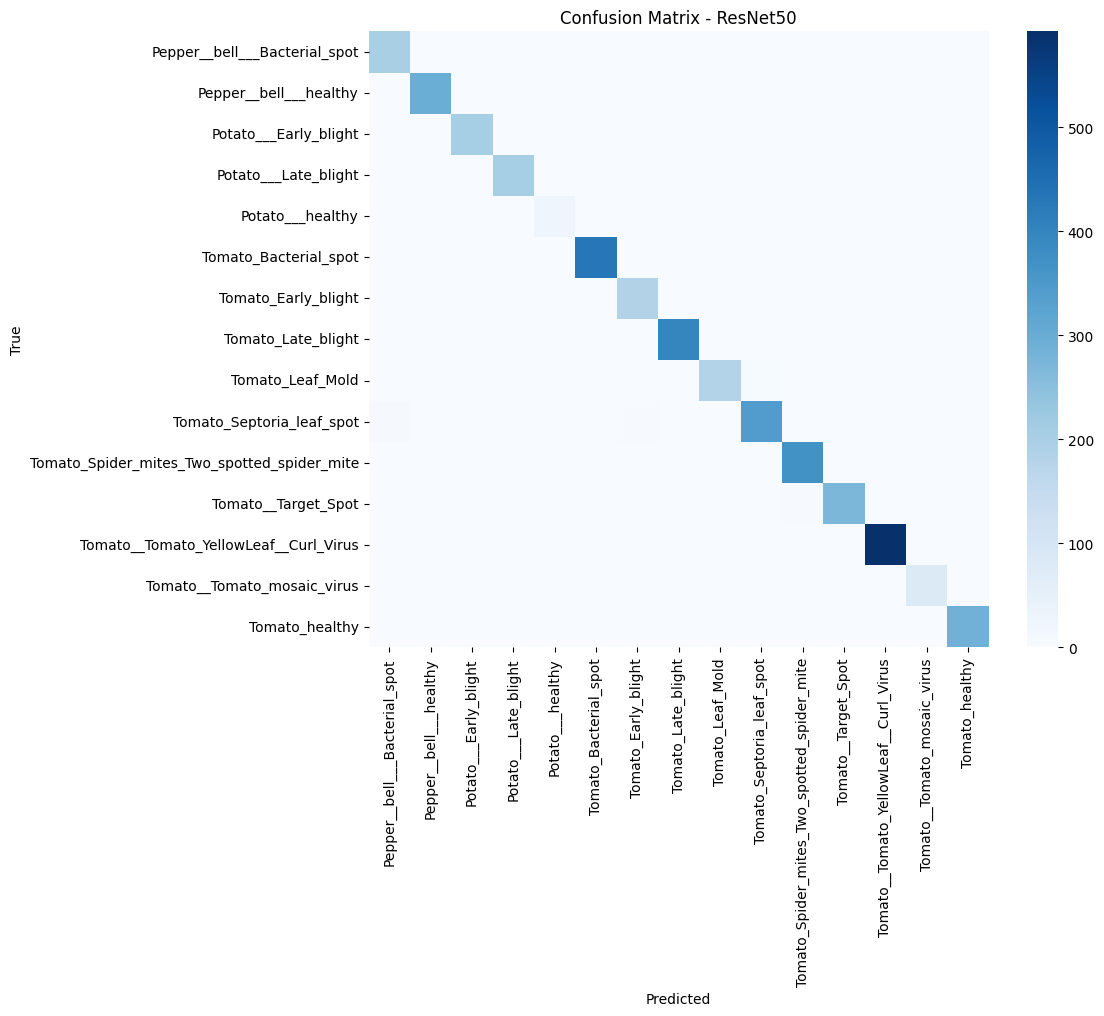

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      1.00      0.98       202
                     Pepper__bell___healthy       1.00      1.00      1.00       298
                      Potato___Early_blight       1.00      1.00      1.00       207
                       Potato___Late_blight       1.00      0.99      0.99       210
                           Potato___healthy       0.97      1.00      0.98        29
                      Tomato_Bacterial_spot       1.00      1.00      1.00       433
                        Tomato_Early_blight       0.96      0.98      0.97       188
                         Tomato_Late_blight       0.99      0.99      0.99       404
                           Tomato_Leaf_Mold       0.99      0.96      0.98       190
                  Tomato_Septoria_leaf_spot       0.98      0.97      0.97       356
Tomato_Spider_mites_Two_spotted_spider_mi

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Validation
all_preds = []
all_labels = []

model_resnet.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=dataset.classes))


In [19]:
##### ----- TEST set-----#####
from sklearn.metrics import accuracy_score

# test set
all_preds_test = []
all_labels_test = []

model_resnet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# total Accuracy
test_accuracy = accuracy_score(all_labels_test, all_preds_test)
print(f"Test Accuracy (ResNet50): {test_accuracy*100:.2f}%")

# Classification Report on test
print("Classification Report (Test Set):")
print(classification_report(all_labels_test, all_preds_test, target_names=dataset.classes))


Test Accuracy (ResNet50): 99.18%
Classification Report (Test Set):
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      1.00      0.98       118
                     Pepper__bell___healthy       1.00      1.00      1.00       144
                      Potato___Early_blight       1.00      1.00      1.00        98
                       Potato___Late_blight       0.99      1.00      1.00       100
                           Potato___healthy       0.94      1.00      0.97        16
                      Tomato_Bacterial_spot       1.00      1.00      1.00       212
                        Tomato_Early_blight       0.95      1.00      0.98       104
                         Tomato_Late_blight       1.00      0.99      1.00       211
                           Tomato_Leaf_Mold       0.99      0.96      0.97        77
                  Tomato_Septoria_leaf_spot       0.99      0.95      0.97       1

In [20]:
# Saving the Model
torch.save(model_resnet.state_dict(), "resnet50_plantvillage.pth")
print("Model saved as resnet50_plantvillage.pth")


Model saved as resnet50_plantvillage.pth


In [21]:
# Testing the model with a real image
from PIL import Image

# file path
img_path = "/content/drive/MyDrive/tomato blight3.png"

# load the image
img = Image.open(img_path).convert("RGB")

# change the size and preparing train
img_tensor = transform(img).unsqueeze(0).to(device)

# load the model
model_resnet.load_state_dict(torch.load("resnet50_plantvillage.pth"))
model_resnet.eval()

with torch.no_grad():
    output = model_resnet(img_tensor)
    _, predicted = torch.max(output, 1)

print("Predicted class:", dataset.classes[predicted.item()])


Predicted class: Pepper__bell___healthy


In [22]:
from PIL import Image

# file path
img_path = "/content/drive/MyDrive/late-blight-tom-leaf.jpg"

# load the image
img = Image.open(img_path).convert("RGB")

# change the size and preparing train
img_tensor = transform(img).unsqueeze(0).to(device)

# load the model
model_resnet.load_state_dict(torch.load("resnet50_plantvillage.pth"))
model_resnet.eval()

with torch.no_grad():
    output = model_resnet(img_tensor)
    _, predicted = torch.max(output, 1)

print("Predicted class:", dataset.classes[predicted.item()])


Predicted class: Tomato_Late_blight
